# Introduction

**Customer Segmentation and Clustering Algorithms in Unsupervised Learning**

- First of all, Unsupervised Learning refers to the effort to make observation units meaningful in situations where there is no dependent variable in machine learning models.

- The goal in unsupervised learning is to discover patterns or relationships in the data.

- From this perspective, unsupervised learning is often used for Exploratory Data Analysis (EDA) and can be used to identify patterns or relationships that may not be immediately noticeable when looking at raw data.

- The data we will be working on today contains purchase history data obtained from membership cards given to customers of a large shopping center, and it is desired to segment this data based on these records.

- The data has been previously processed, feature engineered, and is ready for use.

- Using this data, we will divide our customers into clusters or groups using different methods and analyze these groups to derive insights.

- Before that, we will perform EDA to understand and familiarize ourselves with the data, which will help us to perform more accurate clustering.

**1. Introduction:**

- **Domain Knowledge:**
   - In the modern retail world, customer data is invaluable. Shopping malls analyze customer habits, preferences, and demographic information to offer more personalized experiences. Such personalization can enhance customer loyalty and drive sales.

- **Dataset Introduction:**
   - The "Mall_Customers" dataset contains valuable information about shopping mall customers, collected to support this goal. This dataset includes basic demographic and economic information such as customers' age, gender, annual income, and spending.

- **Importance of the Dataset:**
   - Customer segmentation is a critical tool for tailoring marketing strategies and campaigns to individuals. The "Mall_Customers" dataset provides a foundation for this segmentation, offering valuable insights to retailers and marketers.

- **Objective of Our Project:**
   - In this project, we aim to perform customer segmentation using unsupervised learning techniques with the "Mall_Customers" dataset. This segmentation will provide in-depth insights into customer behavior at the shopping mall, offering opportunities to deliver more personalized services.

**2. Features of the Dataset:**
   - **Customer ID:** A unique identifier assigned to each customer.
   - **Gender:** The gender of the customer.

# Tasks

**1. Import Libraries**
- Import Libraries

**2. Exploratory Data Analysis (EDA)**

**3. Cluster Analysis with K-Means**

- Clustering based on Age and Spending Score

    *i. Create a new dataset with two variables of your choice*
    
    *ii. Determine optimal number of clusters*
    
    *iii. Apply K Means*
    
    *iv. Visualizing and Labeling All the Clusters*
    
    
- Clustering based on Annual Income and Spending Score

    *i. Create a new dataset with two variables of your choice*
    
    *ii. Determine optimal number of clusters*
    
    *iii. Apply K Means*
    
    *iv. Visualizing and Labeling All the Clusters*
    
    
**4. Hierarchical Clustering**

    *i. Determine optimal number of clusters using Dendogram*

    *ii. Apply Agglomerative Clustering*

    *iii. Visualizing and Labeling All the Clusters* 

**5.Conclusion**

### Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# from sklearn.preprocessing import StandardScaler
plt.rcParams["figure.figsize"] = (10,6)
import warnings
warnings.filterwarnings('ignore')
#pd.set_option('display.max_rows', 500)

# Exploratory Data Analysis (EDA)

In [4]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
df.info()

# no null value

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
df.describe().T

# nrmally distributed with same mean, sd can describe the type of distribution.

,count,mean,std,min,25%,50%,75%,max
CustomerID,200.0,100.50,57.879185,1.0,50.75,100.5,150.25,200.0
Age,200.0,38.85,13.969007,18.0,28.75,36.0,49.00,70.0
Annual Income (k$),200.0,60.56,26.264721,15.0,41.50,61.5,78.00,137.0
Spending Score (1-100),200.0,50.20,25.823522,1.0,34.75,50.0,73.00,99.0


## Distribution Analysis

<Axes: xlabel='Age', ylabel='Count'>

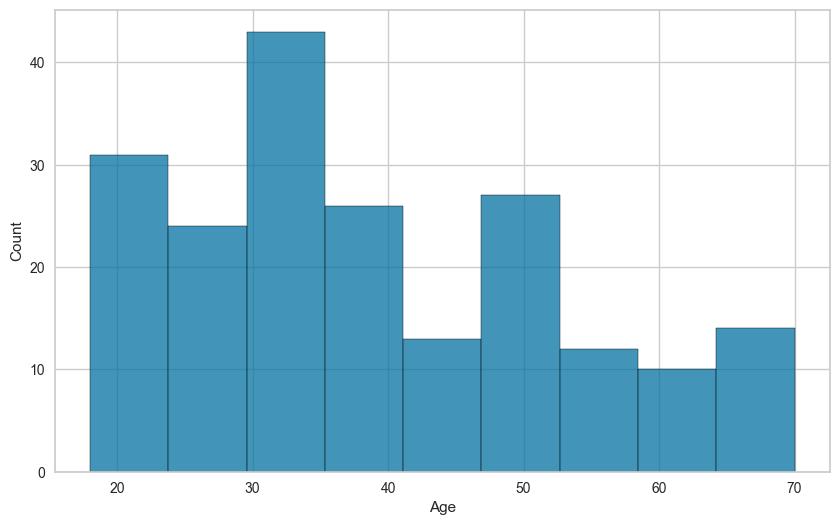

In [7]:
sns.histplot(df['Age'])

<Axes: xlabel='Annual Income (k$)', ylabel='Count'>

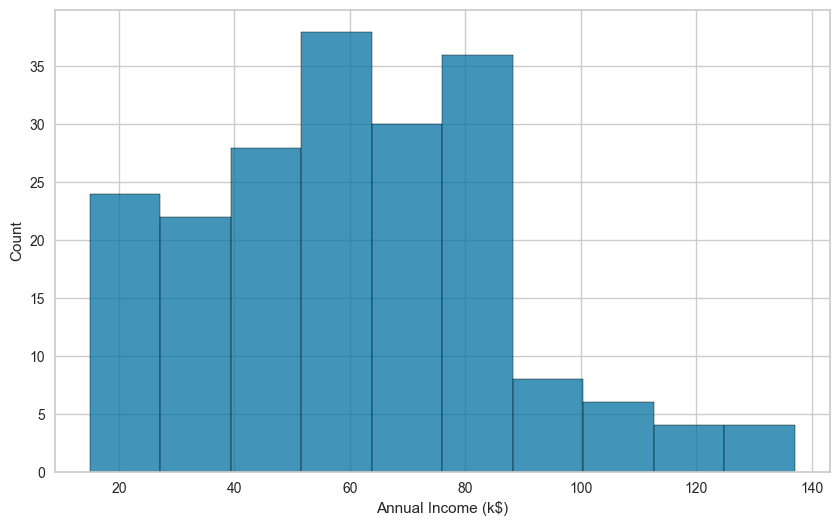

In [8]:
sns.histplot(df['Annual Income (k$)'])

<Axes: xlabel='Spending Score (1-100)', ylabel='Count'>

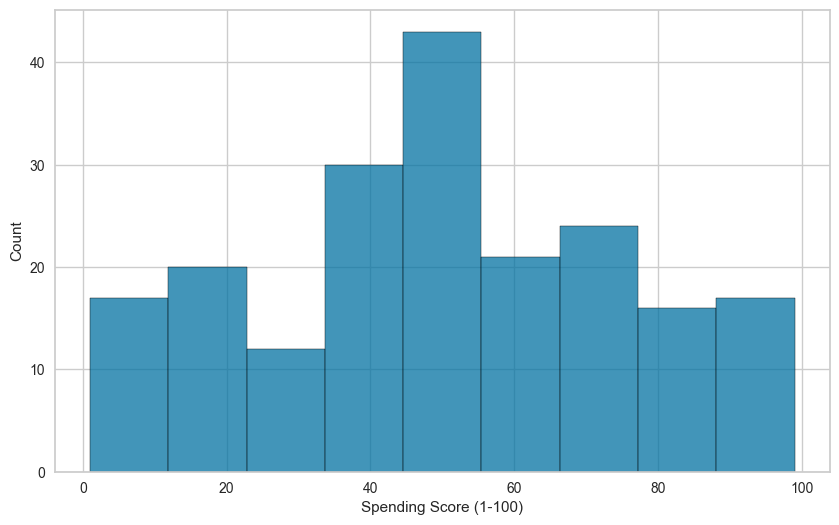

In [9]:
sns.histplot(df['Spending Score (1-100)'])

## Gender Analysis

<Axes: xlabel='Gender', ylabel='count'>

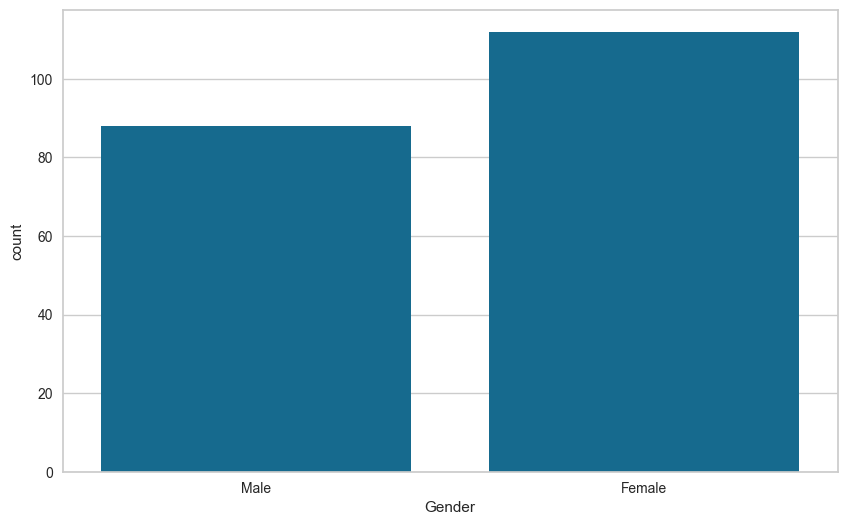

In [10]:
df['Gender'].value_counts()
sns.countplot(x='Gender', data=df)

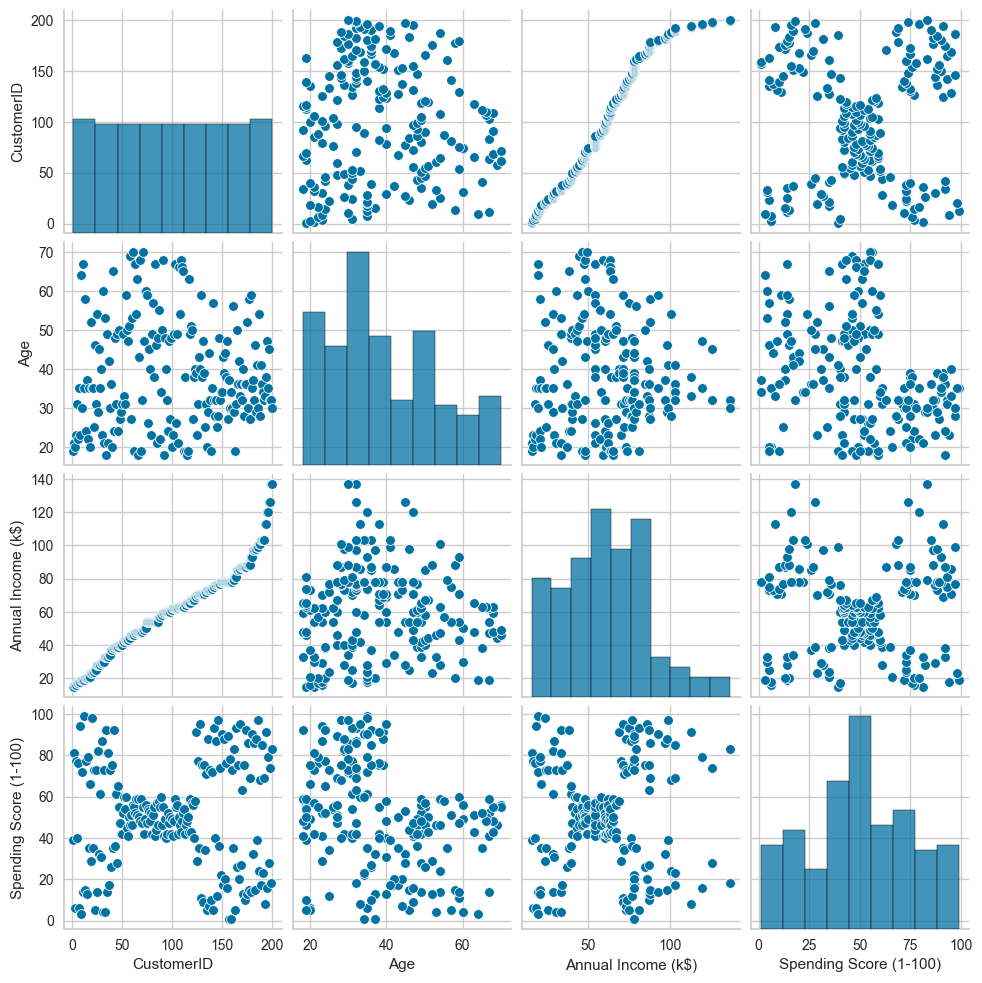

In [11]:
sns.pairplot(df)
plt.show();

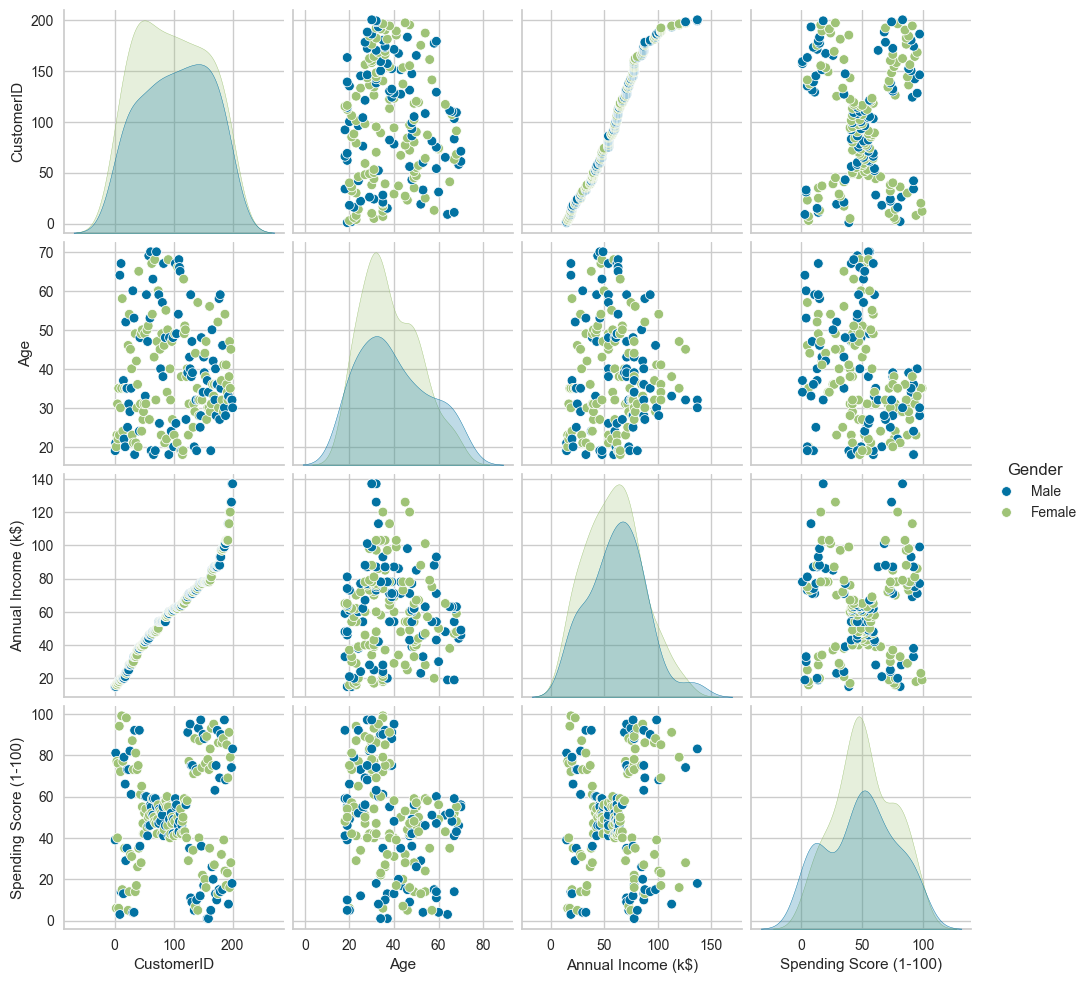

In [12]:
sns.pairplot(data=df, hue='Gender')
plt.show();

## Feature Engineering

In [13]:
df_copy = df.copy()
df_copy.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [14]:
# Dropping CustomerID as it is not useful for clustering
df_copy.drop(columns=['CustomerID'], inplace=True)
# Converting Gender to numeric
df_copy['Gender'] = df_copy['Gender'].map({'Male':0, 'Female':1})
df_copy.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40


## Hopkins test

- The code block below will manually calculate the Hopkins test score
- A score close to 0 will indicate a better clustering tendency

In [15]:
from sklearn.neighbors import BallTree  # BallTree is a data structure used to quickly perform distance queries between data points. 
import numpy as np
import pandas as pd
def hopkins(data_frame, sampling_size):
    """Assess the clusterability of a dataset. A score between 0 and 1, a score around 0.5 express
    no clusterability and a score tending to 0 express a high cluster tendency.
    Parameters
    ----------
    data_frame : numpy array
        The input dataset
    sampling_size : int
        The sampling size which is used to evaluate the number of DataFrame.
    Returns
    ---------------------
    score : float
        The hopkins score of the dataset (between 0 and 1)
    Examples
    --------
    >>> from sklearn import datasets
    >>> from pyclustertend import hopkins
    >>> X = datasets.load_iris().data
    >>> hopkins(X,150)
    0.16
    """
    if type(data_frame) == np.ndarray:
        data_frame = pd.DataFrame(data_frame)
    # Sample n observations from D : P
    if sampling_size > data_frame.shape[0]:
        raise Exception(
            'The number of sample of sample is bigger than the shape of D')
    data_frame_sample = data_frame.sample(n=sampling_size)
    # Get the distance to their neirest neighbors in D : X
    tree = BallTree(data_frame, leaf_size=2)
    dist, _ = tree.query(data_frame_sample, k=2)
    data_frame_sample_distances_to_nearest_neighbours = dist[:, 1]
    # Randomly simulate n points with the same variation as in D : Q.
    max_data_frame = data_frame.max()
    min_data_frame = data_frame.min()
    uniformly_selected_values_0 = np.random.uniform(min_data_frame[0], max_data_frame[0], sampling_size)
    uniformly_selected_values_1 = np.random.uniform(min_data_frame[1], max_data_frame[1], sampling_size)
    uniformly_selected_observations = np.column_stack((uniformly_selected_values_0, uniformly_selected_values_1))
    if len(max_data_frame) >= 2:
        for i in range(2, len(max_data_frame)):
            uniformly_selected_values_i = np.random.uniform(min_data_frame[i], max_data_frame[i], sampling_size)
            to_stack = (uniformly_selected_observations, uniformly_selected_values_i)
            uniformly_selected_observations = np.column_stack(to_stack)
    uniformly_selected_observations_df = pd.DataFrame(uniformly_selected_observations)
    # Get the distance to their neirest neighbors in D : Y
    tree = BallTree(data_frame, leaf_size=2)
    dist, _ = tree.query(uniformly_selected_observations_df, k=1)
    uniformly_df_distances_to_nearest_neighbours = dist
    # return the hopkins score
    x = sum(data_frame_sample_distances_to_nearest_neighbours)
    y = sum(uniformly_df_distances_to_nearest_neighbours)
    if x + y == 0:
        raise Exception('The denominator of the hopkins statistics is null')
    return x / (x + y)[0]


In [16]:
Z = df_copy
hopkins(Z,Z.shape[0]) 

np.float64(0.33363608627020663)

In [17]:
hopkins(Z, 60)

np.float64(0.28713480294761384)

# K_Means Clustering

## Age and Spending Score - X1

In [18]:
Z.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40


In [19]:
X1 = Z[['Age', 'Spending Score (1-100)']]

In [20]:
X1.head()

,Age,Spending Score (1-100)
0,19,39
1,21,81
2,20,6
3,23,77
4,31,40


In [21]:
X1.shape

(200, 2)

In [22]:
Z1 = X1.copy()

### Scaling Data

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X1_scaled = scaler.fit_transform(X1)

In [24]:
from sklearn.cluster import KMeans

In [25]:
K_means_model_X1 = KMeans(n_clusters=5, random_state=42)

# n_clusters: Number of Clusters

**NOTE**: In K-Means, `fit` and `predict` are usually used together. **When `fit` is called, it captures patterns and creates centroids.** When `predict` is called, it assigns data points to their nearest clusters.


In [26]:
K_means_model_X1.fit_predict(X1_scaled)   # Here, both `fit` and `predict` are used together.

array([2, 1, 4, 1, 2, 1, 4, 1, 3, 1, 3, 1, 3, 1, 4, 1, 4, 2, 3, 1, 4, 1,
       3, 1, 3, 1, 3, 2, 4, 1, 3, 1, 3, 1, 3, 1, 3, 1, 4, 1, 0, 1, 3, 2,
       3, 2, 0, 2, 2, 2, 0, 2, 2, 0, 0, 0, 0, 0, 2, 0, 0, 2, 0, 0, 0, 2,
       0, 0, 2, 2, 0, 0, 0, 0, 0, 2, 0, 2, 2, 0, 0, 2, 0, 0, 2, 0, 0, 2,
       2, 0, 0, 2, 0, 4, 2, 2, 0, 2, 0, 2, 2, 0, 0, 2, 0, 2, 0, 0, 0, 0,
       0, 2, 4, 2, 2, 2, 0, 0, 0, 0, 2, 4, 2, 1, 4, 1, 3, 1, 3, 1, 3, 1,
       2, 1, 4, 1, 3, 1, 4, 1, 3, 1, 2, 1, 4, 1, 3, 1, 4, 1, 3, 1, 3, 1,
       3, 1, 4, 1, 4, 1, 0, 1, 4, 1, 3, 1, 3, 1, 4, 2, 4, 1, 4, 1, 3, 1,
       3, 1, 3, 1, 4, 1, 3, 1, 4, 1, 3, 1, 4, 1, 4, 1, 4, 1, 3, 1, 3, 1,
       4, 1], dtype=int32)

In [27]:
Z1["Classes"] = K_means_model_X1.labels_    # Let's assign the labels above to classes
Z1

,Age,Spending Score (1-100),Classes
0,19,39,2
1,21,81,1
2,20,6,4
3,23,77,1
4,31,40,2
...,...,...,...
195,35,79,1
196,45,28,3
197,32,74,1
198,32,18,4


**NOTE**: In the above steps, we created KMeans clusters by setting `n_clusters=5` and using the default parameters. However, we don't yet know if the model is successful. To determine this, we would need an expert's recommendation on the appropriate number of clusters for the Iris dataset.

------------------------------------------------

Now, let's apply the methods to determine the optimal number of clusters.

### Choosing The Optimal Number of Clusters

We don't have domain knowledge, we'll need to rely on mathematical methods to determine the optimal number of clusters

#### Elbow method

In [28]:
ssd1 = []    # inertia  .. SSD, "Sum of Squared Distances"

K1 = range(2,10)   # started with minimum 2 clusters

for k in K1:                                          # For each different number of clusters, a K-Means model is created and trained.
    model = KMeans(n_clusters =k, random_state=42)
    model.fit(X1_scaled)
    ssd1.append(model.inertia_)

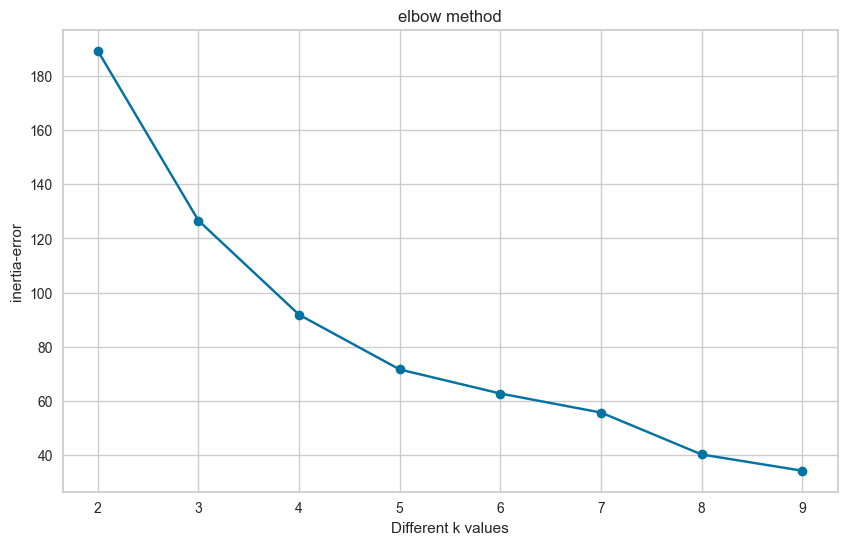

In [29]:
plt.plot(K1, ssd1, "bo-")
plt.xlabel("Different k values")
plt.ylabel("inertia-error") 
plt.title("elbow method") 
plt.show()

Here, we can see that the first sharp drop occurs at 3 clusters. However, let's also visualize this numerically using a bar chart.

In [30]:
ssd1    # calculated above..  sum of sqaured distance

[189.38749033992428,
 126.63343205080366,
 91.82344759859048,
 71.5906989173433,
 62.69793709571269,
 55.66326693818969,
 40.17162448370207,
 34.168841096196275]

In [31]:
pd.Series(ssd1).diff()

# The first row is 0 because "152 - nothing." We're looking for the largest drop.

0          NaN
1   -62.754058
2   -34.809984
3   -20.232749
4    -8.892762
5    -7.034670
6   -15.491642
7    -6.002783
dtype: float64

In [32]:
# transform the values above to a dataframe.
df_diff1 =pd.DataFrame(-pd.Series(ssd1).diff()).rename(index = lambda x : x+1)
df_diff1

,0
1,NaN
2,62.754058
3,34.809984
4,20.232749
5,8.892762
6,7.034670
7,15.491642
8,6.002783


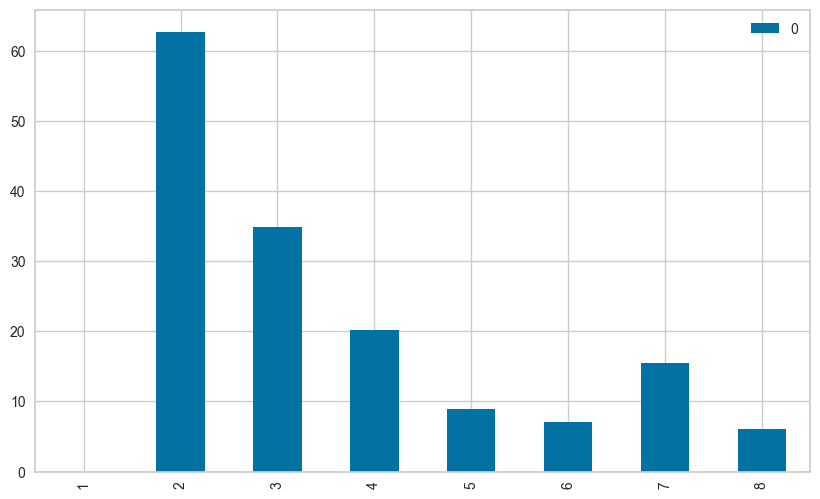

In [33]:
df_diff1.plot(kind='bar');    # Let's identify the point of the sharpest drop based on the graph below.

**NOTE:** The sharpest drop is observed at 3 clusters. However, we will also try to confirm this using Yellowbrick.

#### Second Method - Yellowbrick (n_cluster selection)

In [34]:
pip install yellowbrick

Note: you may need to restart the kernel to use updated packages.


In [35]:
pip install -U scikit-learn yellowbrick

  Using cached scikit_learn-1.8.0-cp313-cp313-macosx_12_0_arm64.whl.metadata (11 kB)
Using cached scikit_learn-1.8.0-cp313-cp313-macosx_12_0_arm64.whl (8.0 MB)
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.5.2
    Uninstalling scikit-learn-1.5.2:
      Successfully uninstalled scikit-learn-1.5.2
Note: you may need to restart the kernel to use updated packages.


In [36]:
import sklearn
import yellowbrick

In [37]:
pip install "scikit-learn<1.6" "yellowbrick==1.5" matplotlib pandas numpy

  Using cached scikit_learn-1.5.2-cp313-cp313-macosx_12_0_arm64.whl.metadata (13 kB)
Using cached scikit_learn-1.5.2-cp313-cp313-macosx_12_0_arm64.whl (11.0 MB)
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.8.0
    Uninstalling scikit-learn-1.8.0:
      Successfully uninstalled scikit-learn-1.8.0
Note: you may need to restart the kernel to use updated packages.


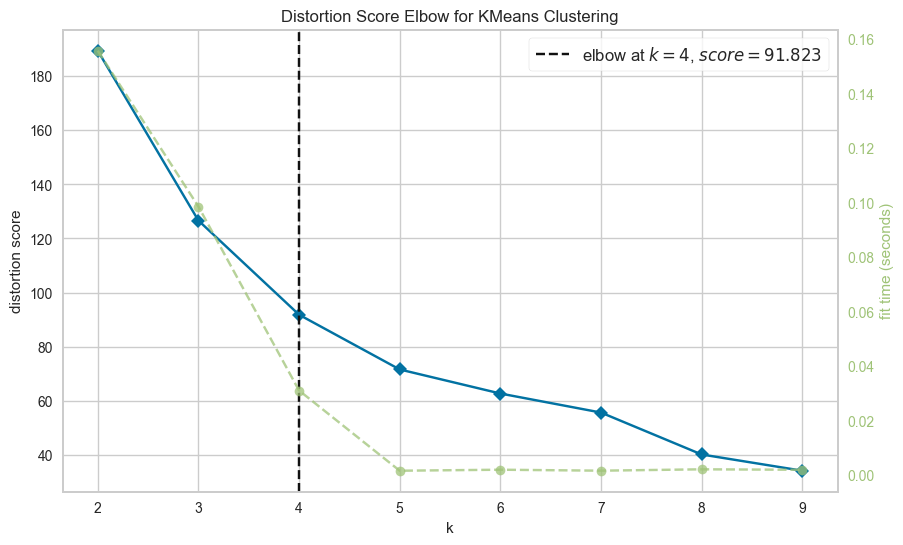

In [38]:
from yellowbrick.cluster import KElbowVisualizer   # Uses Yellowbrick to visualize the elbow point in the graph

model_1 = KMeans(random_state=42)
visualizer_1 = KElbowVisualizer(model_1, k=(2,10))  # Evaluates the model for each cluster count between 2 and 10

visualizer_1.fit(X1_scaled)        # Fit the data to the visualizer.. Shows according to the inertia method
visualizer_1.show();


### Silhouette analysis

In [39]:
from sklearn.metrics import silhouette_score

In [40]:
silhouette_score(X1_scaled, K_means_model_X1.labels_)   # the default value of n_cluster =5

np.float64(0.41027764008333134)

In [41]:
range_n_clusters_x1 = range(2,9)
for num_clusters in range_n_clusters_x1:
    # intialise kmeans
    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    kmeans.fit(X1_scaled)
    cluster_labels = kmeans.labels_
    # silhouette score
    silhouette_avg_x1 = silhouette_score(X1_scaled, cluster_labels)
    print(f"For n_clusters={num_clusters}, the silhouette score is {silhouette_avg_x1}")

For n_clusters=2, the silhouette score is 0.47212716430695223
For n_clusters=3, the silhouette score is 0.4314135260969647
For n_clusters=4, the silhouette score is 0.4144782638216291
For n_clusters=5, the silhouette score is 0.41027764008333134
For n_clusters=6, the silhouette score is 0.41873999503015313
For n_clusters=7, the silhouette score is 0.37819665165695193
For n_clusters=8, the silhouette score is 0.3997720888593656


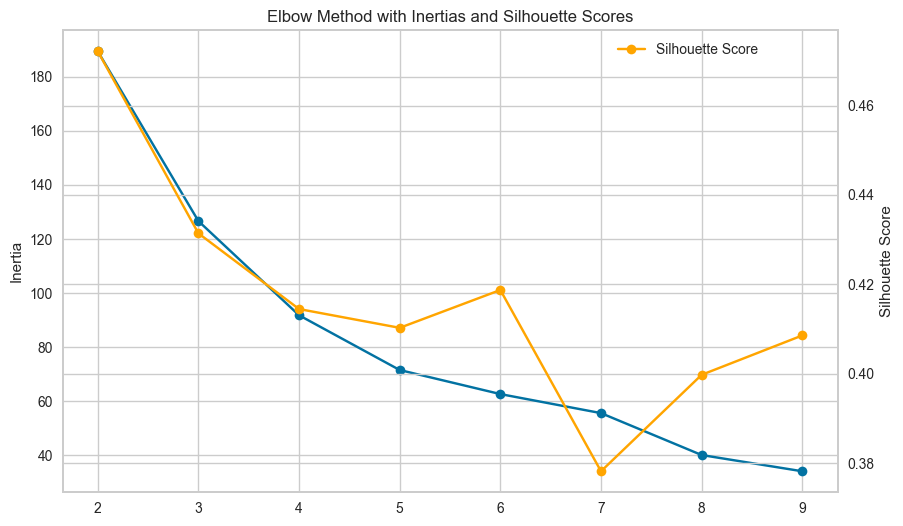

In [42]:
# A visual that shows the scores of both K Means and Silhouette

inertia_scores_x1 = []
silhouette_scores_x1 = []
for i in range(2, 10):
    model = KMeans(n_clusters=i, random_state=42)
    labels = model.fit_predict(X1_scaled)
    silhouette = silhouette_score(X1_scaled, labels)
    inertia = model.inertia_
    inertia_scores_x1.append(inertia)
    silhouette_scores_x1.append(silhouette)
# Plotting the Elbow Method with Inertias and Silhouette Scores
plt.figure(figsize=(10, 6))
# Plot Inertias
plt.plot(range(2,10), inertia_scores_x1, label='Inertia', marker='o')
plt.ylabel('Inertia')
# Plot Silhouette Scores on a secondary y-axis
plt.twinx()
plt.plot(range(2,10), silhouette_scores_x1, label='Silhouette Score', marker='o', color='orange')
# Add labels, title, and legend
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Elbow Method with Inertias and Silhouette Scores')
plt.legend(loc='upper left', bbox_to_anchor=(0.7, 1))
plt.show()

We can state that the best balance, based on the graph above, appears to be at 3 clusters.

### Silhouette Visualizer

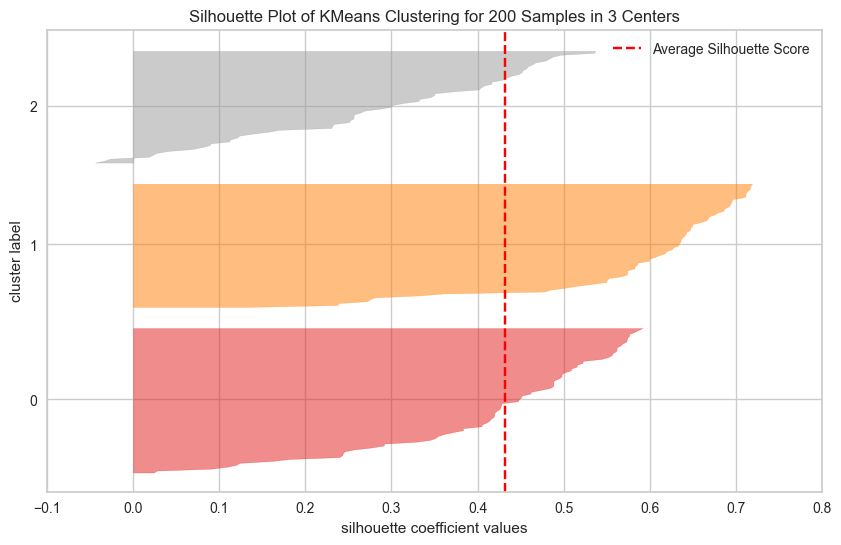

In [43]:
from sklearn.cluster import KMeans

from yellowbrick.cluster import SilhouetteVisualizer

model3_x1 = KMeans(n_clusters=3, random_state=42)  # selected kmeans = 3 
visualizer = SilhouetteVisualizer(model3_x1)

visualizer.fit(X1_scaled)    # Fit the data to the visualizer
visualizer.poof();

**Points to Consider When Interpreting the SilhouetteVisualizer:**

- **Wide silhouettes** (values close to 1) indicate good clustering performance.
- **Narrow or negative silhouettes** suggest that these data points may have been assigned to the wrong cluster.
- If many data points fall below the **average silhouette score** (indicated by the red dashed line), it might be necessary to reconsider the number of clusters.

#### Building the model based on the optimal number of clusters

In [44]:
# n_cluster =3

In [45]:
model_x1 = KMeans(n_clusters =3, random_state=42)
model_x1.fit_predict(X1_scaled)

array([2, 1, 2, 1, 2, 1, 2, 1, 0, 1, 0, 1, 0, 1, 2, 1, 2, 1, 0, 1, 2, 1,
       0, 1, 0, 1, 0, 1, 2, 1, 0, 1, 0, 1, 0, 1, 0, 1, 2, 1, 0, 1, 0, 1,
       0, 1, 0, 2, 2, 2, 0, 1, 2, 0, 0, 0, 0, 0, 2, 0, 0, 2, 0, 0, 0, 2,
       0, 0, 2, 2, 0, 0, 0, 0, 0, 2, 0, 2, 2, 0, 0, 2, 0, 0, 2, 0, 0, 2,
       1, 0, 0, 2, 0, 2, 2, 2, 0, 2, 0, 2, 2, 0, 0, 2, 0, 2, 0, 0, 0, 0,
       0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 2, 2, 1, 1, 2, 1, 0, 1, 0, 1, 0, 1,
       2, 1, 2, 1, 0, 1, 2, 1, 0, 1, 2, 1, 2, 1, 0, 1, 2, 1, 0, 1, 0, 1,
       0, 1, 2, 1, 2, 1, 0, 1, 2, 1, 0, 1, 0, 1, 2, 1, 2, 1, 2, 1, 0, 1,
       0, 1, 0, 1, 2, 1, 0, 1, 2, 1, 0, 1, 2, 1, 2, 1, 2, 1, 0, 1, 0, 1,
       2, 1], dtype=int32)

In [46]:
model_x1.labels_    # n_cluster= 3

array([2, 1, 2, 1, 2, 1, 2, 1, 0, 1, 0, 1, 0, 1, 2, 1, 2, 1, 0, 1, 2, 1,
       0, 1, 0, 1, 0, 1, 2, 1, 0, 1, 0, 1, 0, 1, 0, 1, 2, 1, 0, 1, 0, 1,
       0, 1, 0, 2, 2, 2, 0, 1, 2, 0, 0, 0, 0, 0, 2, 0, 0, 2, 0, 0, 0, 2,
       0, 0, 2, 2, 0, 0, 0, 0, 0, 2, 0, 2, 2, 0, 0, 2, 0, 0, 2, 0, 0, 2,
       1, 0, 0, 2, 0, 2, 2, 2, 0, 2, 0, 2, 2, 0, 0, 2, 0, 2, 0, 0, 0, 0,
       0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 2, 2, 1, 1, 2, 1, 0, 1, 0, 1, 0, 1,
       2, 1, 2, 1, 0, 1, 2, 1, 0, 1, 2, 1, 2, 1, 0, 1, 2, 1, 0, 1, 0, 1,
       0, 1, 2, 1, 2, 1, 0, 1, 2, 1, 0, 1, 0, 1, 2, 1, 2, 1, 2, 1, 0, 1,
       0, 1, 0, 1, 2, 1, 0, 1, 2, 1, 0, 1, 2, 1, 2, 1, 2, 1, 0, 1, 0, 1,
       2, 1], dtype=int32)

In [47]:
clusters_x1 = model_x1.labels_

In [48]:
Z1.head()

,Age,Spending Score (1-100),Classes
0,19,39,2
1,21,81,1
2,20,6,4
3,23,77,1
4,31,40,2


In [49]:
Z1["predicted_clusters"] = clusters_x1
Z1
# Here, the prediction results can be seen within the predicted feature.

,Age,Spending Score (1-100),Classes,predicted_clusters
0,19,39,2,2
1,21,81,1,1
2,20,6,4,2
3,23,77,1,1
4,31,40,2,2
...,...,...,...,...
195,35,79,1,1
196,45,28,3,0
197,32,74,1,1
198,32,18,4,2


### Visualization Clusters

In [50]:
Z1.head()

,Age,Spending Score (1-100),Classes,predicted_clusters
0,19,39,2,2
1,21,81,1,1
2,20,6,4,2
3,23,77,1,1
4,31,40,2,2


Performing the visualization based on (predicted_clusters) of my model.

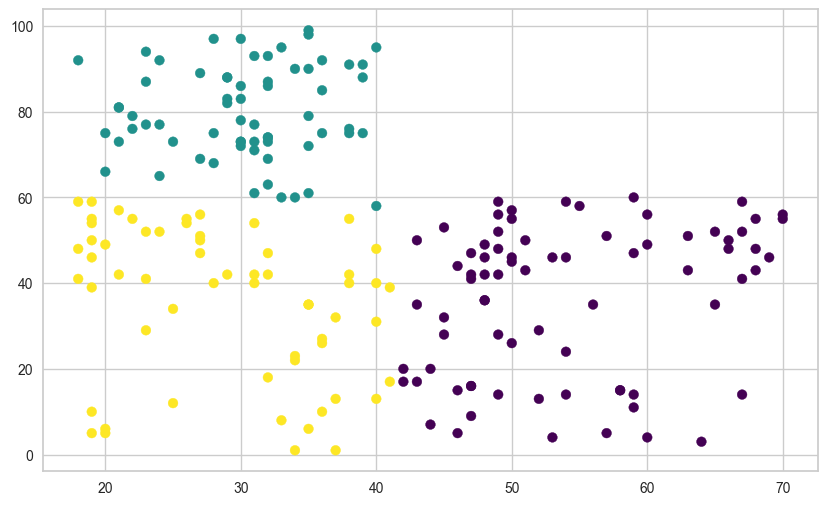

In [51]:
plt.scatter(Z1["Age"], Z1["Spending Score (1-100)"], c = Z1["predicted_clusters"], cmap = "viridis");

## Annual Income and Spending Score - X2

In [52]:
X2 = Z[['Annual Income (k$)', 'Spending Score (1-100)']]

In [53]:
X2.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [54]:
Z2 = X2.copy()

### Scaling Data

In [55]:
X2_scaled = scaler.fit_transform(X2)

In [56]:
K_means_model_X2 = KMeans(n_clusters=5, random_state=42)
K_means_model_X2.fit_predict(X2_scaled)

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

In [57]:
Z2["Classes"] = K_means_model_X2.labels_    # Let's assign the labels above to classes
Z2

,Annual Income (k$),Spending Score (1-100),Classes
0,15,39,4
1,15,81,2
2,16,6,4
3,16,77,2
4,17,40,4
...,...,...,...
195,120,79,1
196,126,28,3
197,126,74,1
198,137,18,3


### Hopkins test

In [58]:
hopkins(X2_scaled,X2_scaled.shape[0])  # can be taken as %10-20 for big datas (for ex 150 thousands)

np.float64(0.31119462332375786)

In [59]:
hopkins(X2_scaled, 60) # I looked at the scores for 60 observations, and they are close. 
# The scores may vary with each run, but there won't be a significant difference.

np.float64(0.29215159580849553)

### Choosing The Optimal Number of Clusters

#### Elbow method

In [60]:
ssd2 = []    # inertia  .. SSD, "Sum of Squared Distances"

K2 = range(2,10)   # started with minimum 2 clusters

for k in K2:                                          # For each different number of clusters, a K-Means model is created and trained.
    model = KMeans(n_clusters =k, random_state=42)
    model.fit(X2_scaled)
    ssd2.append(model.inertia_)

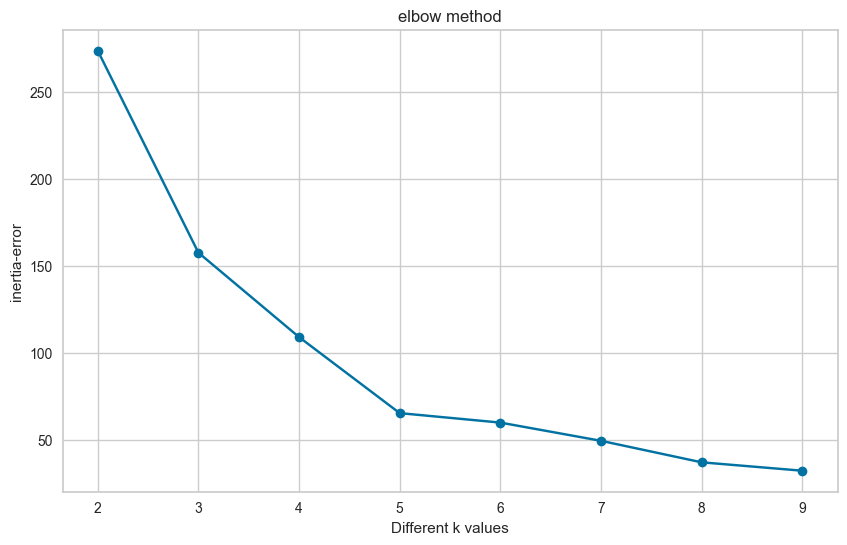

In [61]:
plt.plot(K2, ssd2, "bo-")
plt.xlabel("Different k values")
plt.ylabel("inertia-error") 
plt.title("elbow method") 
plt.show()

Here, we can see that the first sharp drop occurs at 3 clusters. However, let's also visualize this numerically using a bar chart.

In [62]:
ssd2    # calculated above..  sum of sqaured distance

[273.6688866264201,
 157.7040081503595,
 109.22822707921344,
 65.56840815571681,
 60.13287487193422,
 49.66824483736798,
 37.319122878338824,
 32.49508119910091]

In [63]:
pd.Series(ssd2).diff()

# The first row is 0 because "152 - nothing." We're looking for the largest drop.

0           NaN
1   -115.964878
2    -48.475781
3    -43.659819
4     -5.435533
5    -10.464630
6    -12.349122
7     -4.824042
dtype: float64

In [64]:
# transform the values above to a dataframe.
df_diff2 =pd.DataFrame(-pd.Series(ssd2).diff()).rename(index = lambda x : x+1)
df_diff2

,0
1,NaN
2,115.964878
3,48.475781
4,43.659819
5,5.435533
6,10.464630
7,12.349122
8,4.824042


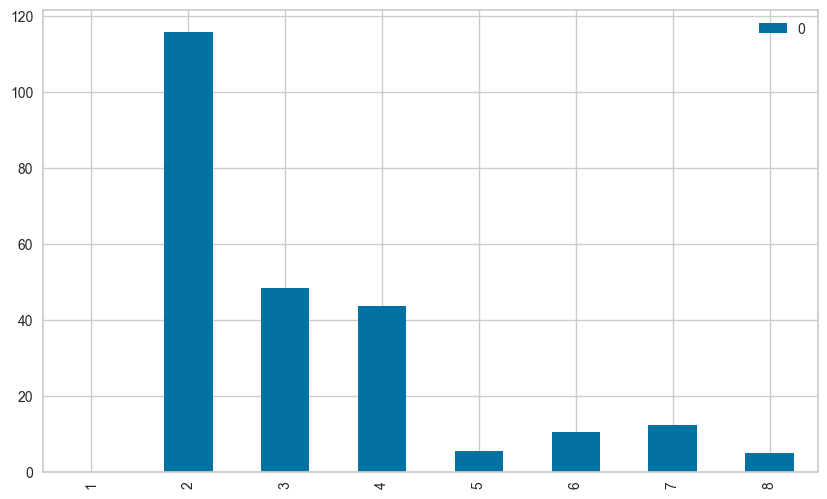

In [65]:
df_diff2.plot(kind='bar');    # Let's identify the point of the sharpest drop based on the graph below.

**NOTE:** The sharpest drop is observed at 3 clusters. However, we will also try to confirm this using Yellowbrick.

#### Second Method - Yellowbrick (n_cluster selection)

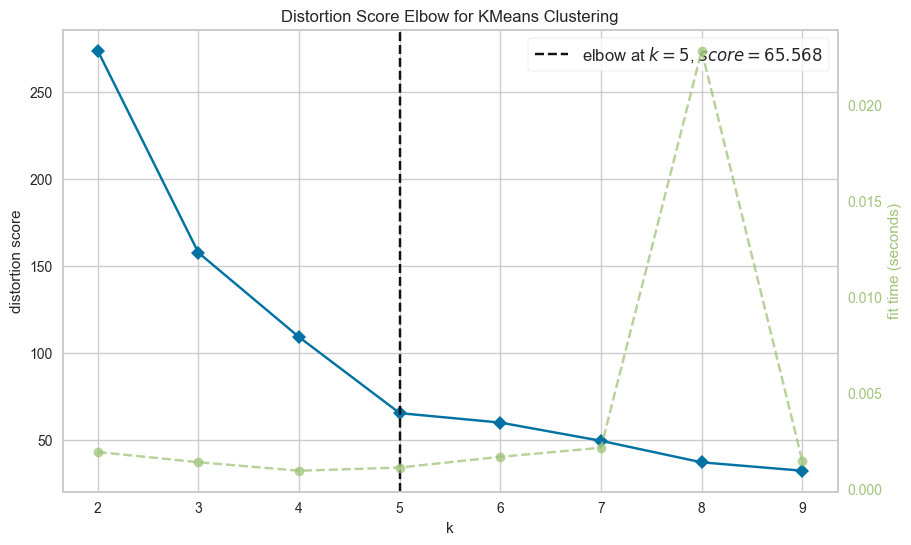

In [66]:
model_2 = KMeans(random_state=42)
visualizer_2 = KElbowVisualizer(model_2, k=(2,10))  # Evaluates the model for each cluster count between 2 and 10

visualizer_2.fit(X2_scaled)        # Fit the data to the visualizer.. Shows according to the inertia method
visualizer_2.show();

### Silhouette analysis

In [67]:
silhouette_score(X2_scaled, K_means_model_X2.labels_)   # the default value of n_cluster =5

np.float64(0.5546571631111091)

In [68]:
range_n_clusters_x2 = range(2,9)
for num_clusters in range_n_clusters_x2:
    # intialise kmeans
    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    kmeans.fit(X2_scaled)
    cluster_labels = kmeans.labels_
    # silhouette score
    silhouette_avg_x2 = silhouette_score(X2_scaled, cluster_labels)
    print(f"For n_clusters={num_clusters}, the silhouette score is {silhouette_avg_x2}")

For n_clusters=2, the silhouette score is 0.3973270007887498
For n_clusters=3, the silhouette score is 0.46658474419000145
For n_clusters=4, the silhouette score is 0.49434988482196796
For n_clusters=5, the silhouette score is 0.5546571631111091
For n_clusters=6, the silhouette score is 0.513825753467656
For n_clusters=7, the silhouette score is 0.50200146805547
For n_clusters=8, the silhouette score is 0.4550112502601921


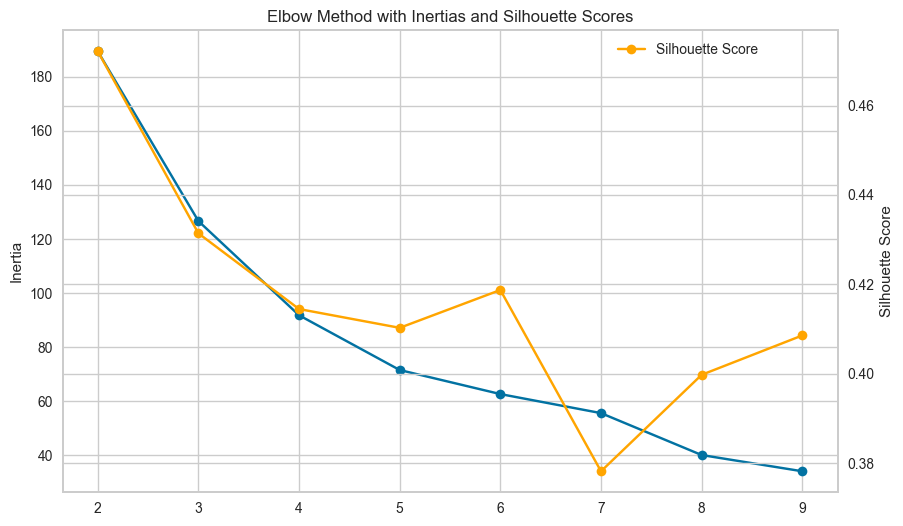

In [69]:
# A visual that shows the scores of both K Means and Silhouette

inertia_scores_x2 = []
silhouette_scores_x2 = []
for i in range(2, 10):
    model = KMeans(n_clusters=i, random_state=42)
    labels = model.fit_predict(X1_scaled)
    silhouette = silhouette_score(X1_scaled, labels)
    inertia = model.inertia_
    inertia_scores_x2.append(inertia)
    silhouette_scores_x2.append(silhouette)
# Plotting the Elbow Method with Inertias and Silhouette Scores
plt.figure(figsize=(10, 6))
# Plot Inertias
plt.plot(range(2,10), inertia_scores_x2, label='Inertia', marker='o')
plt.ylabel('Inertia')
# Plot Silhouette Scores on a secondary y-axis
plt.twinx()
plt.plot(range(2,10), silhouette_scores_x2, label='Silhouette Score', marker='o', color='orange')
# Add labels, title, and legend
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Elbow Method with Inertias and Silhouette Scores')
plt.legend(loc='upper left', bbox_to_anchor=(0.7, 1))
plt.show()

We can state that the best balance, based on the graph above, appears to be at 3 clusters.

### Silhouette Visualizer

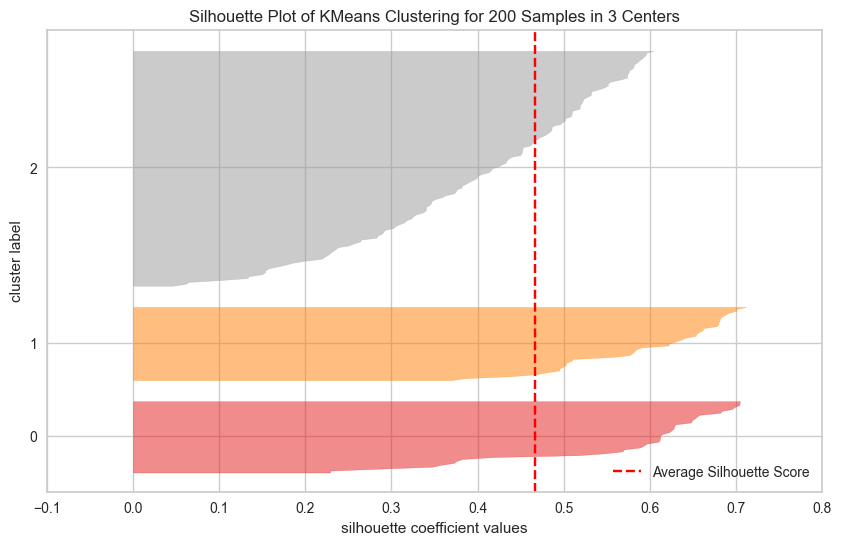

In [70]:
from sklearn.cluster import KMeans

from yellowbrick.cluster import SilhouetteVisualizer

model3_x2 = KMeans(n_clusters=3, random_state=42)  # selected kmeans = 3
visualizer = SilhouetteVisualizer(model3_x2)

visualizer.fit(X2_scaled)    # Fit the data to the visualizer
visualizer.poof();

#### Building the model based on the optimal number of clusters

- n_cluster =3

In [71]:
model_x2 = KMeans(n_clusters =3, random_state=42)
model_x2.fit_predict(X2_scaled)

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1], dtype=int32)

In [72]:
model_x2.labels_    # n_cluster= 3

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1], dtype=int32)

In [73]:
clusters_x2 = model_x2.labels_

In [74]:
Z2.head()

,Annual Income (k$),Spending Score (1-100),Classes
0,15,39,4
1,15,81,2
2,16,6,4
3,16,77,2
4,17,40,4


In [75]:
Z2["predicted_clusters"] = clusters_x2
Z2
# Here, the prediction results can be seen within the predicted feature.

,Annual Income (k$),Spending Score (1-100),Classes,predicted_clusters
0,15,39,4,2
1,15,81,2,2
2,16,6,4,2
3,16,77,2,2
4,17,40,4,2
...,...,...,...,...
195,120,79,1,1
196,126,28,3,0
197,126,74,1,1
198,137,18,3,0


### Visualization Clusters

In [76]:
# Performing the visualization based on (predicted_clusters) of my model.

In [77]:
Z2.head()

,Annual Income (k$),Spending Score (1-100),Classes,predicted_clusters
0,15,39,4,2
1,15,81,2,2
2,16,6,4,2
3,16,77,2,2
4,17,40,4,2


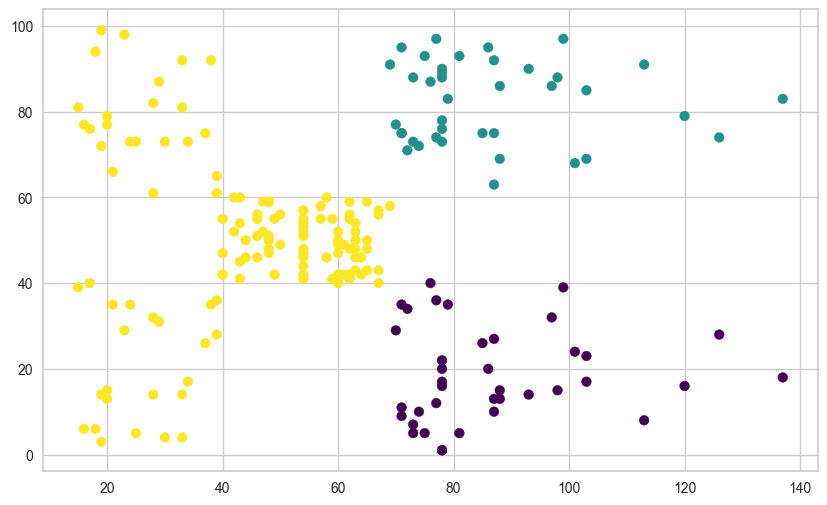

In [78]:
plt.scatter(Z2["Annual Income (k$)"], Z2["Spending Score (1-100)"], c = Z2["predicted_clusters"], cmap = "viridis");

In [79]:
# On above cluster visualization, we can see that the customers are segmented into 5 clusters.
# Based on visuzalization, I will be updating the cluster number to 5 and re-running the model to see the new clusters.

#### Updating the model to 5 clusters

- n_cluster =5

In [80]:
model_x1_update = KMeans(n_clusters =5, random_state=42)
model_x1_update.fit_predict(X2_scaled)

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

In [81]:
model_x1_update.labels_    # n_cluster= 5

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

In [82]:
clusters_x1_updated = model_x1_update.labels_

In [83]:
Z2["predicted_clusters"] = clusters_x1_updated
Z2
# Here, the prediction results can be seen within the predicted feature.

,Annual Income (k$),Spending Score (1-100),Classes,predicted_clusters
0,15,39,4,4
1,15,81,2,2
2,16,6,4,4
3,16,77,2,2
4,17,40,4,4
...,...,...,...,...
195,120,79,1,1
196,126,28,3,3
197,126,74,1,1
198,137,18,3,3


### Visualization New updated Clusters

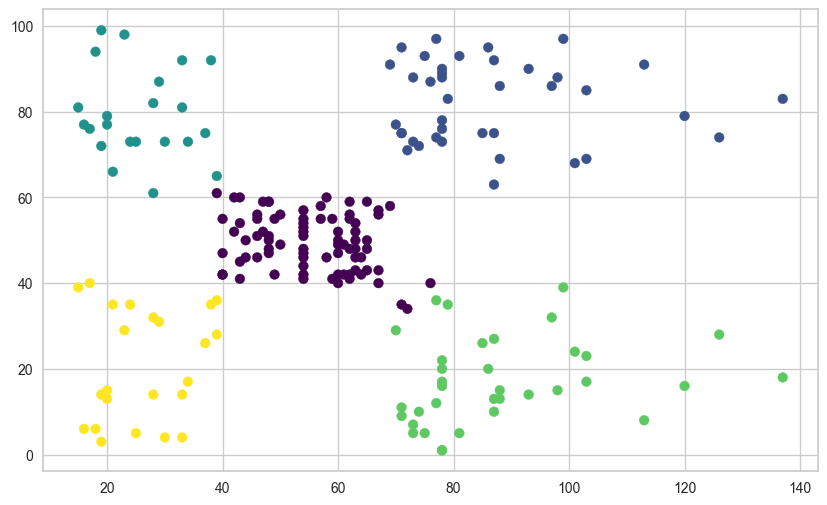

In [84]:
plt.scatter(Z2["Annual Income (k$)"], Z2["Spending Score (1-100)"], c = Z2["predicted_clusters"], cmap = "viridis");

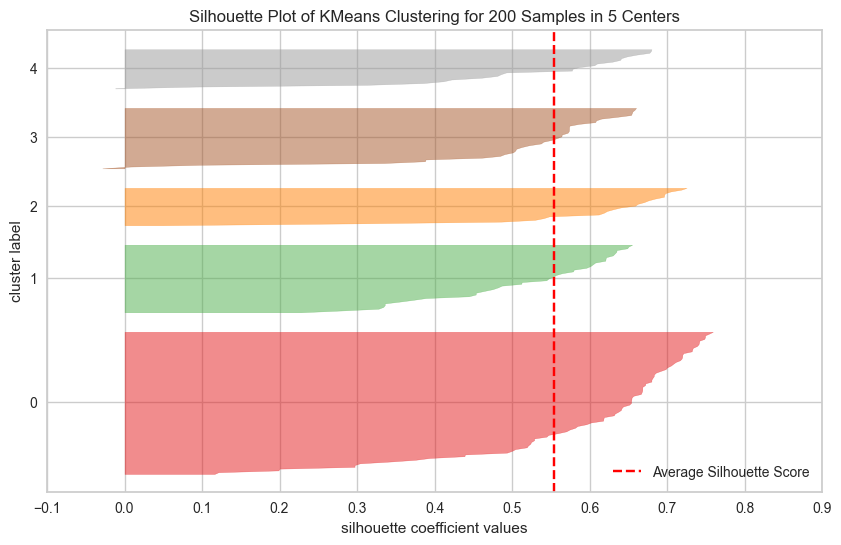

In [125]:
from sklearn.cluster import KMeans

from yellowbrick.cluster import SilhouetteVisualizer

model3_x2_updated = KMeans(n_clusters=5, random_state=42)  # selected kmeans = 3
visualizer = SilhouetteVisualizer(model3_x2_updated)

visualizer.fit(X2_scaled)    # Fit the data to the visualizer
visualizer.poof();

# Hierarchical Clustering

## Age and Spending Score- X1

In [86]:
Z.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40


In [87]:
X1_Hierarchy = Z[['Age', 'Spending Score (1-100)']]

In [88]:
X1_Hierarchy.head()

,Age,Spending Score (1-100)
0,19,39
1,21,81
2,20,6
3,23,77
4,31,40


In [89]:
X1_Hierarchy_scaled = scaler.fit_transform(X1_Hierarchy)

### Dendrogram

- Unlike K-Means, we can see the ideal number of clusters using a dendrogram without creating any model.

In [90]:
from scipy.cluster.hierarchy import dendrogram, linkage

In [91]:
hc_ward_X1 = linkage(y= X1_Hierarchy_scaled, method="ward")

hc_complete_X1 = linkage(X1_Hierarchy_scaled, "complete")
hc_average_X1 = linkage(X1_Hierarchy_scaled, "average")
hc_single_X1 = linkage(X1_Hierarchy_scaled, "single")

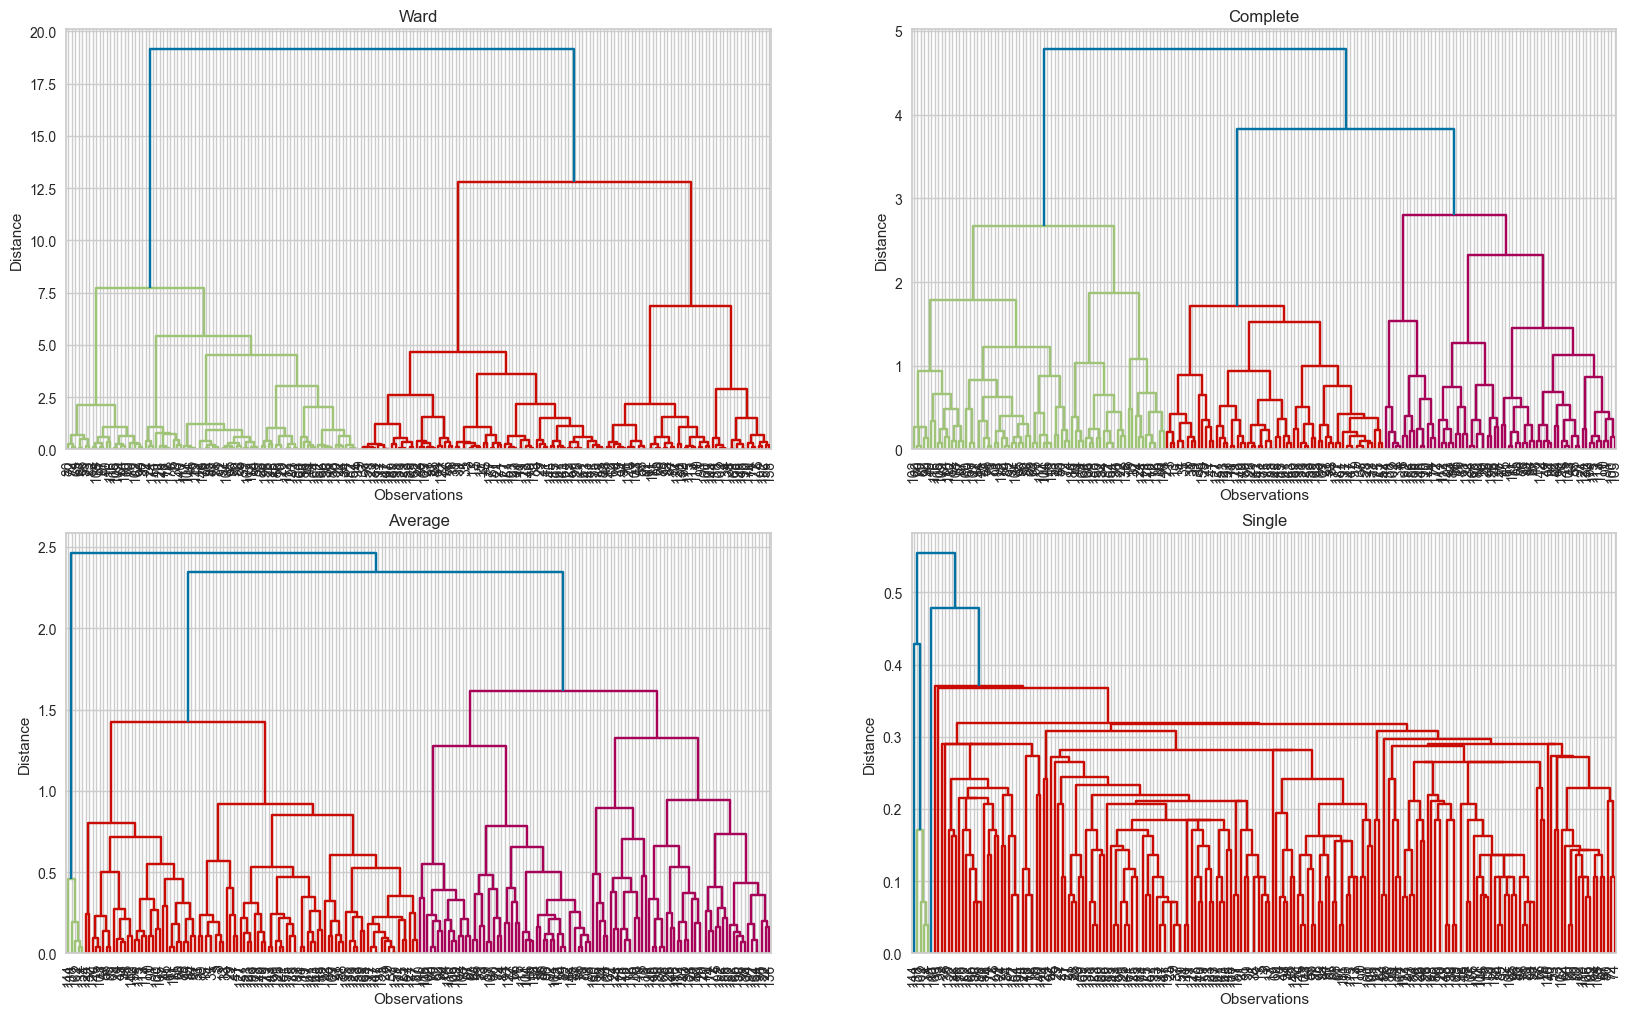

In [92]:
# Let's create the dendrogram according to the above linkage calculation

# dendrogram plot based on all methods 

plt.figure(figsize = (20,12))

plt.subplot(221)
plt.title("Ward")
plt.xlabel("Observations")
plt.ylabel("Distance")
dendrogram(hc_ward_X1, leaf_font_size = 10)

plt.subplot(222)
plt.title("Complete")
plt.xlabel("Observations")
plt.ylabel("Distance")
dendrogram(hc_complete_X1, leaf_font_size = 10)

plt.subplot(223)
plt.title("Average")
plt.xlabel("Observations")
plt.ylabel("Distance")
dendrogram(hc_average_X1, leaf_font_size = 10)

plt.subplot(224)
plt.title("Single")
plt.xlabel("Observations")
plt.ylabel("Distance")
dendrogram(hc_single_X1, leaf_font_size = 10);

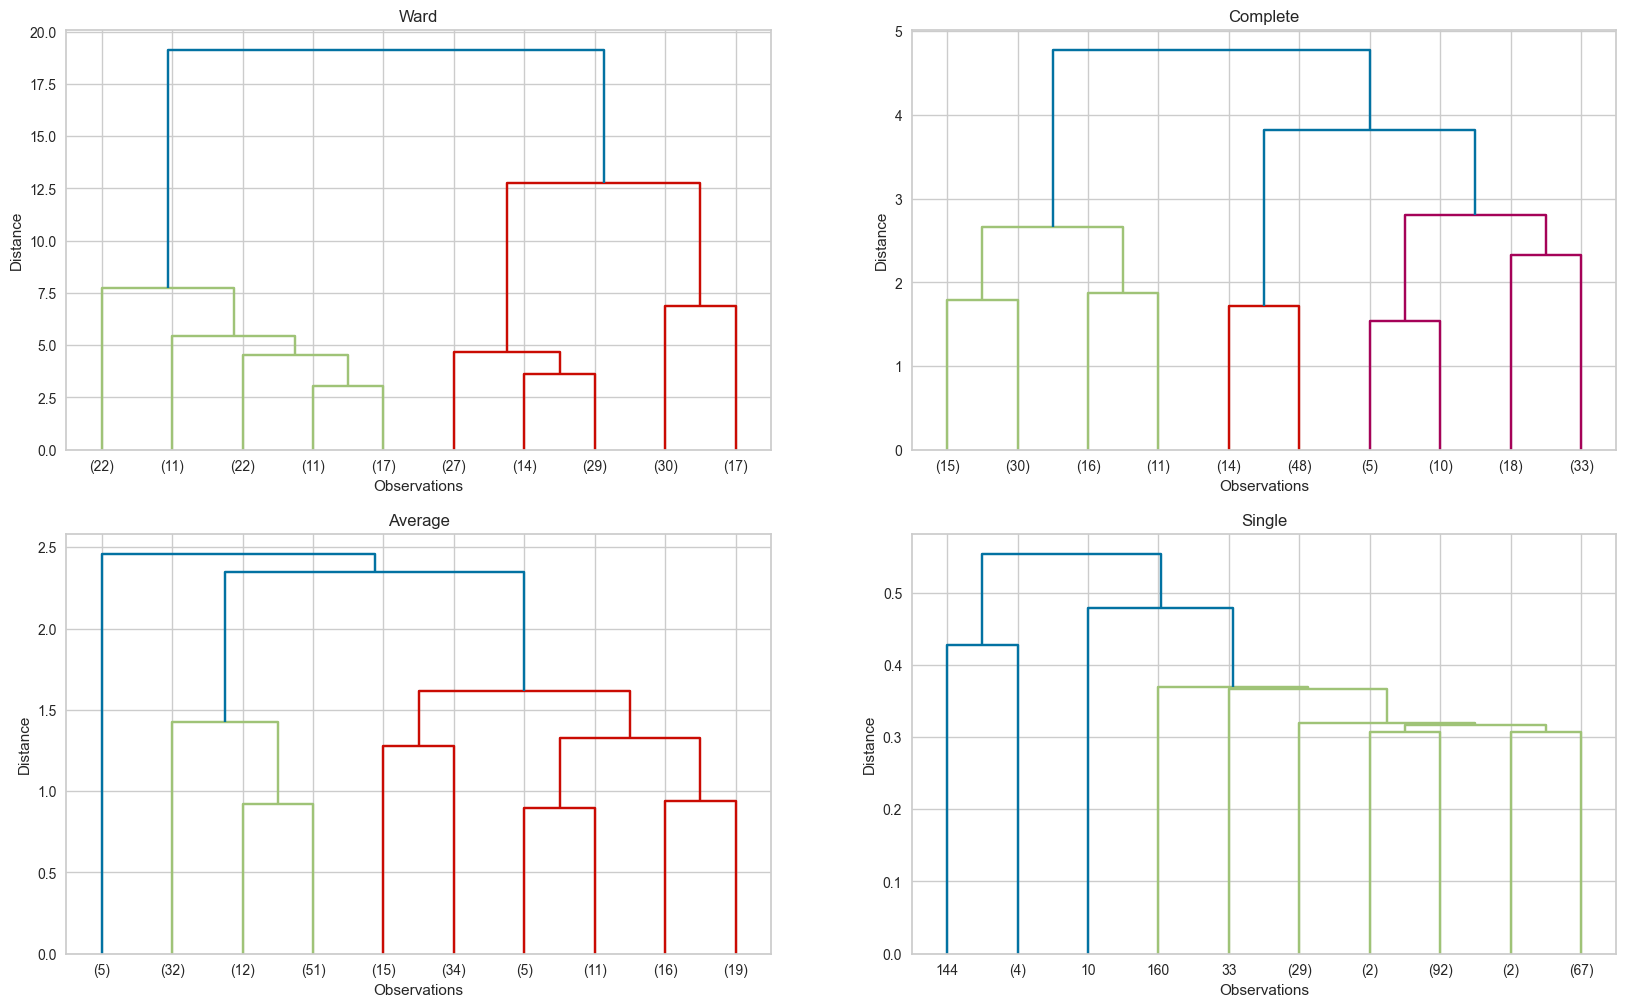

In [93]:
# let's simplify the graphics

plt.figure(figsize = (20,12))

plt.subplot(221)
plt.title("Ward")
plt.xlabel("Observations")
plt.ylabel("Distance")
dendrogram(hc_ward_X1, leaf_font_size = 10, truncate_mode='lastp', p=10)

plt.subplot(222)
plt.title("Complete")
plt.xlabel("Observations")
plt.ylabel("Distance")
dendrogram(hc_complete_X1, leaf_font_size = 10, truncate_mode='lastp', p=10)

plt.subplot(223)
plt.title("Average")
plt.xlabel("Observations")
plt.ylabel("Distance")
dendrogram(hc_average_X1, leaf_font_size = 10, truncate_mode='lastp', p=10)

plt.subplot(224)
plt.title("Single")
plt.xlabel("Observations")
plt.ylabel("Distance")
dendrogram(hc_single_X1, leaf_font_size = 10, truncate_mode='lastp' , p=10);  # p the number of clusers created in last branches

we will proceed with 3 clusters

### Hierarchical Clustering (Agglomerative)

In [94]:
from sklearn.cluster import AgglomerativeClustering

#### Silhouette Score

In [95]:
from sklearn.metrics import silhouette_score

**Before determining the number of clusters, let's evaluate the silhouette score for the range from 2 to 10 clusters. The clustering method to be used is Agglomerative Clustering.**

In [96]:
K= range (2,10)
for k in K:
    model =AgglomerativeClustering(n_clusters = k)
    model.fit_predict(X1_Hierarchy_scaled)
    print(f'Silhouette Score for {k} clusters: {silhouette_score(X1_Hierarchy_scaled, model.labels_)}')

Silhouette Score for 2 clusters: 0.41449964268829986
Silhouette Score for 3 clusters: 0.4166414852049989
Silhouette Score for 4 clusters: 0.38927004893647266
Silhouette Score for 5 clusters: 0.3764554127969015
Silhouette Score for 6 clusters: 0.3990690566558254
Silhouette Score for 7 clusters: 0.358604678369238
Silhouette Score for 8 clusters: 0.361081283331325
Silhouette Score for 9 clusters: 0.3659083749836485


Highest scroe on silhouette score is also 3.

In [97]:
model1_X1 =  AgglomerativeClustering(n_clusters=3,linkage = "ward") 
model1_X1.fit_predict(X1_Hierarchy_scaled)

array([1, 2, 1, 2, 1, 2, 1, 2, 0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 0, 2,
       0, 2, 0, 1, 1, 1, 0, 2, 2, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       2, 0, 1, 1, 0, 0, 0, 0, 0, 1, 2, 2, 1, 0, 0, 2, 0, 0, 1, 0, 0, 1,
       2, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 2, 2, 1, 2, 0, 2, 0, 2, 0, 2,
       1, 2, 1, 2, 0, 2, 1, 2, 0, 2, 1, 2, 1, 2, 0, 2, 1, 2, 0, 2, 0, 2,
       0, 2, 1, 2, 1, 2, 0, 2, 1, 2, 0, 2, 0, 2, 1, 2, 1, 2, 1, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 1, 2, 1, 2, 0, 2, 0, 2,
       1, 2])

In [98]:
model1_X1.labels_

# The values below show the cluster assignments obtained using the Agglomerative Clustering technique (prediction).

array([1, 2, 1, 2, 1, 2, 1, 2, 0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 0, 2,
       0, 2, 0, 1, 1, 1, 0, 2, 2, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       2, 0, 1, 1, 0, 0, 0, 0, 0, 1, 2, 2, 1, 0, 0, 2, 0, 0, 1, 0, 0, 1,
       2, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 2, 2, 1, 2, 0, 2, 0, 2, 0, 2,
       1, 2, 1, 2, 0, 2, 1, 2, 0, 2, 1, 2, 1, 2, 0, 2, 1, 2, 0, 2, 0, 2,
       0, 2, 1, 2, 1, 2, 0, 2, 1, 2, 0, 2, 0, 2, 1, 2, 1, 2, 1, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 1, 2, 1, 2, 0, 2, 0, 2,
       1, 2])

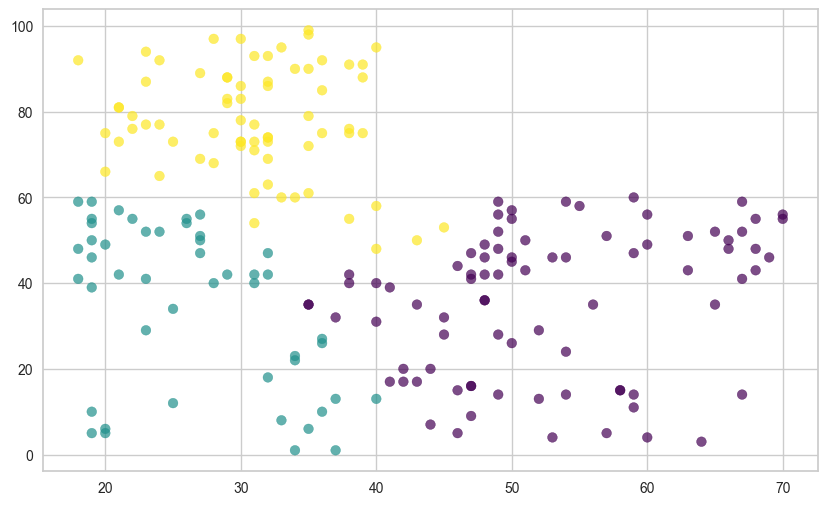

In [99]:
# Let's visualize the newly assigned observations to clusters (not drawn according to real values!!)

plt.scatter(X1_Hierarchy["Age"], X1_Hierarchy["Spending Score (1-100)"], c= model1_X1.labels_, cmap= "viridis", alpha = 0.7);

In [100]:
clusters_x1_hierarchy = model1_X1.labels_      # I assigned my model predictions to the `clusters` variable.

In [101]:
X1_Hierarchy

,Age,Spending Score (1-100)
0,19,39
1,21,81
2,20,6
3,23,77
4,31,40
...,...,...
195,35,79
196,45,28
197,32,74
198,32,18


In [102]:
X1_Hierarchy["predicted_clusters"] = clusters_x1_hierarchy    # added "predicted_clusters" feature to the original data
X1_Hierarchy.head()

,Age,Spending Score (1-100),predicted_clusters
0,19,39,1
1,21,81,2
2,20,6,1
3,23,77,2
4,31,40,1


### S(Silhouette) Score

In [103]:
K = range(2,10)

for k in K:
    model = AgglomerativeClustering(n_clusters = k)
    model.fit_predict(X1_Hierarchy)
    print(f'Silhouette Score for {k} clusters: {silhouette_score(X1_Hierarchy, model.labels_)}')

Silhouette Score for 2 clusters: 0.4549990538837561
Silhouette Score for 3 clusters: 0.4410158098312884
Silhouette Score for 4 clusters: 0.4600368764851615
Silhouette Score for 5 clusters: 0.4034630085108307
Silhouette Score for 6 clusters: 0.4122037696279756
Silhouette Score for 7 clusters: 0.4154818528869761
Silhouette Score for 8 clusters: 0.3878588591269535
Silhouette Score for 9 clusters: 0.39426944696126154


### Final model fo X1

In [104]:
final_model_x1_hierarchy = AgglomerativeClustering(n_clusters=3, linkage = "complete")
clusters = final_model_x1_hierarchy.fit_predict(X1_Hierarchy)

In [105]:
X1_Hierarchy["predicted_clusters"] = clusters
X1_Hierarchy.head()

,Age,Spending Score (1-100),predicted_clusters
0,19,39,0
1,21,81,1
2,20,6,2
3,23,77,1
4,31,40,0


## Annual Income and Spending Score - X2

In [106]:
X2_Hierarchy = Z[['Annual Income (k$)', 'Spending Score (1-100)']]

In [107]:
X2_Hierarchy.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [108]:
X2_Hierarchy_scaled = scaler.fit_transform(X2_Hierarchy)

### Dendrogram

In [109]:
hc_ward_X2 = linkage(y= X2_Hierarchy_scaled, method="ward")

hc_complete_X2 = linkage(X2_Hierarchy_scaled, "complete")
hc_average_X2 = linkage(X2_Hierarchy_scaled, "average")
hc_single_X2 = linkage(X2_Hierarchy_scaled, "single")

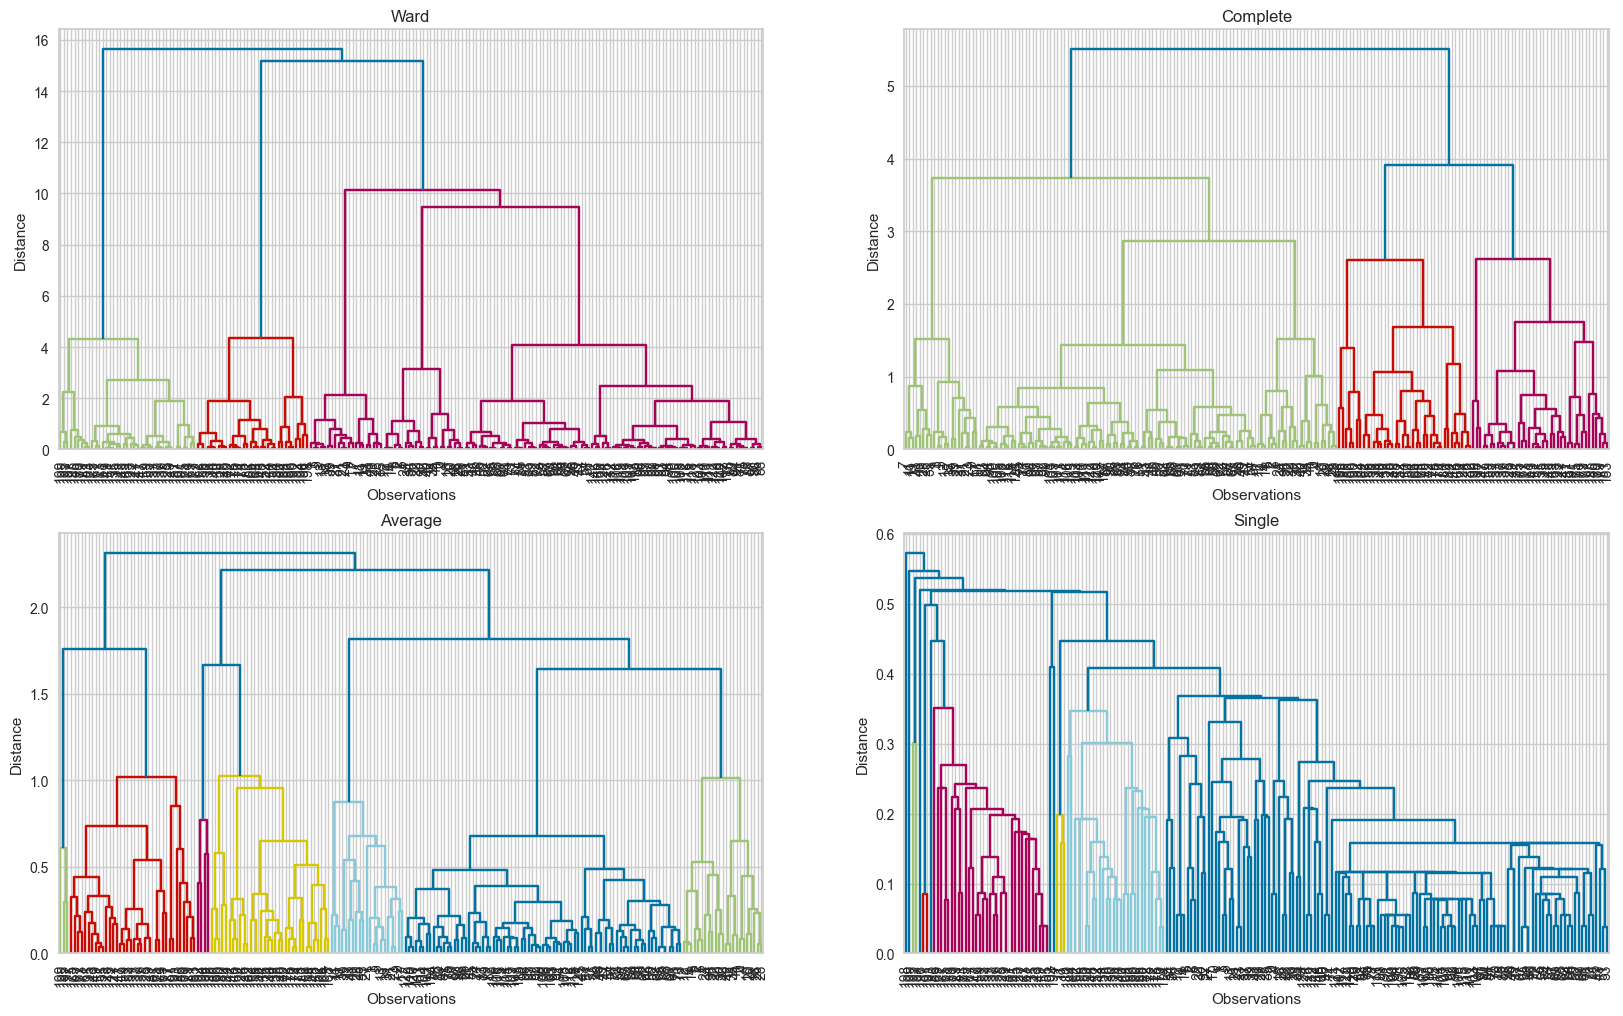

In [110]:
# Let's create the dendrogram according to the above linkage calculation

# dendrogram plot based on all methods 

plt.figure(figsize = (20,12))

plt.subplot(221)
plt.title("Ward")
plt.xlabel("Observations")
plt.ylabel("Distance")
dendrogram(hc_ward_X2, leaf_font_size = 10)

plt.subplot(222)
plt.title("Complete")
plt.xlabel("Observations")
plt.ylabel("Distance")
dendrogram(hc_complete_X2, leaf_font_size = 10)

plt.subplot(223)
plt.title("Average")
plt.xlabel("Observations")
plt.ylabel("Distance")
dendrogram(hc_average_X2, leaf_font_size = 10)

plt.subplot(224)
plt.title("Single")
plt.xlabel("Observations")
plt.ylabel("Distance")
dendrogram(hc_single_X2, leaf_font_size = 10);

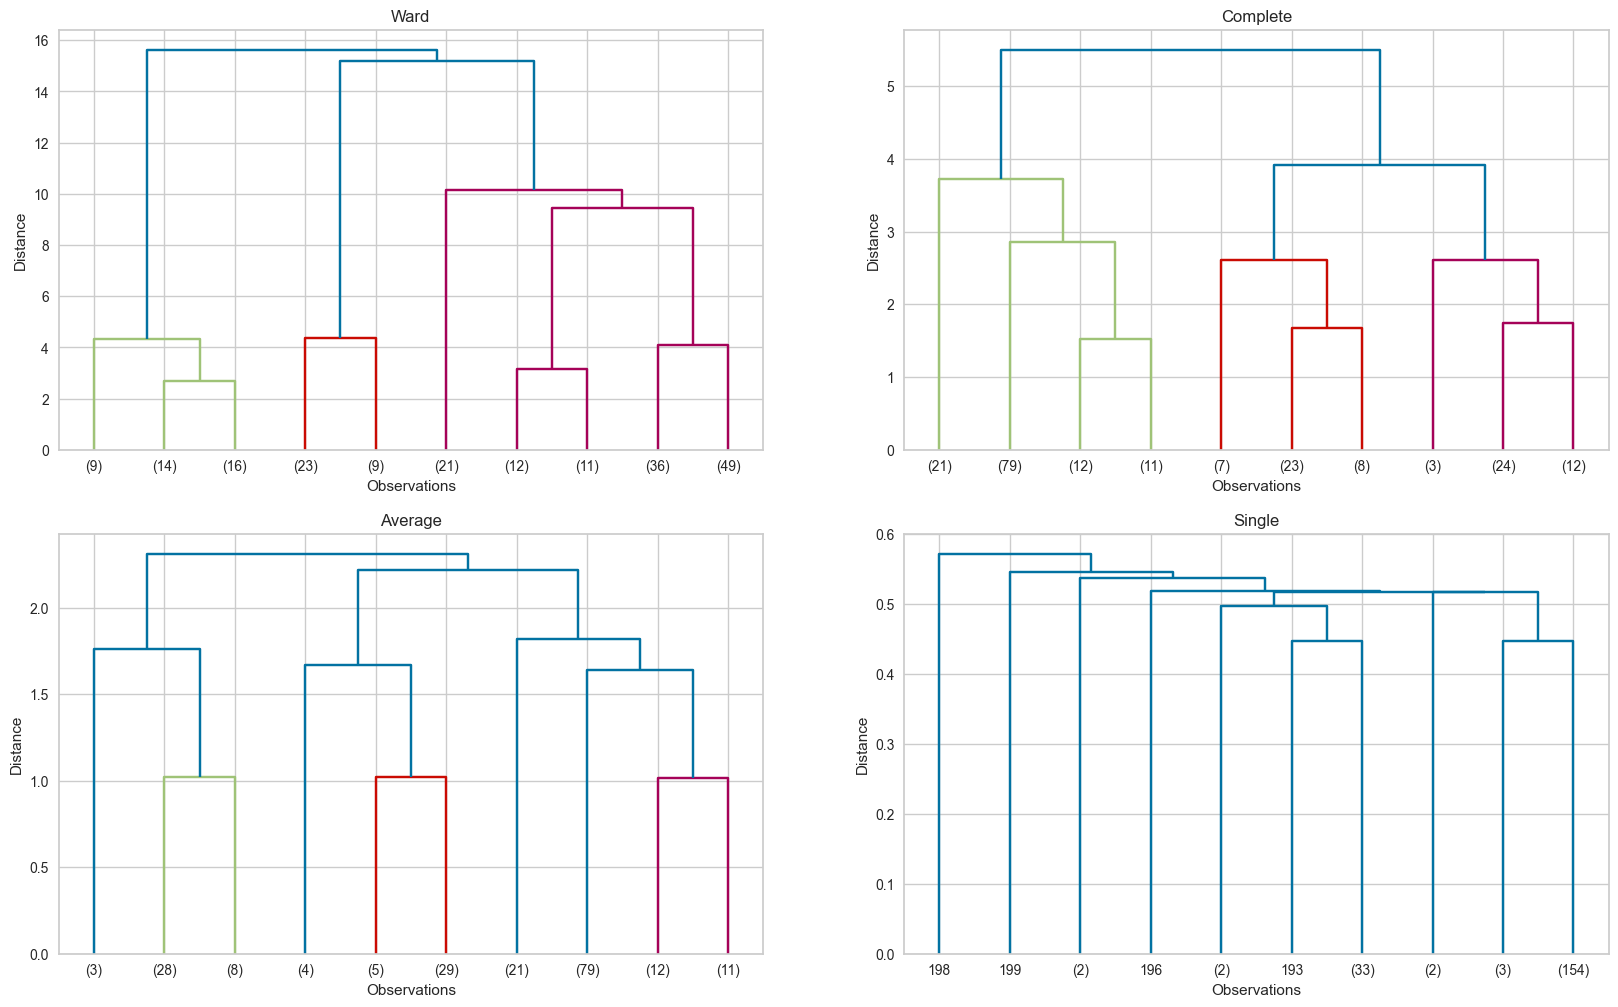

In [111]:
# let's simplify the graphics

plt.figure(figsize = (20,12))

plt.subplot(221)
plt.title("Ward")
plt.xlabel("Observations")
plt.ylabel("Distance")
dendrogram(hc_ward_X2, leaf_font_size = 10, truncate_mode='lastp', p=10)

plt.subplot(222)
plt.title("Complete")
plt.xlabel("Observations")
plt.ylabel("Distance")
dendrogram(hc_complete_X2, leaf_font_size = 10, truncate_mode='lastp', p=10)

plt.subplot(223)
plt.title("Average")
plt.xlabel("Observations")
plt.ylabel("Distance")
dendrogram(hc_average_X2, leaf_font_size = 10, truncate_mode='lastp', p=10)

plt.subplot(224)
plt.title("Single")
plt.xlabel("Observations")
plt.ylabel("Distance")
dendrogram(hc_single_X2, leaf_font_size = 10, truncate_mode='lastp' , p=10);  # p the number of clusers created in last branches

we will proceed with 3 clusters

### Hierarchical Clustering (Agglomerative)

#### Silhouette Score

**Before determining the number of clusters, let's evaluate the silhouette score for the range from 2 to 10 clusters. The clustering method to be used is Agglomerative Clustering.**

In [112]:
K= range (2,10)
for k in K:
    model =AgglomerativeClustering(n_clusters = k)
    model.fit_predict(X2_Hierarchy_scaled)
    print(f'Silhouette Score for {k} clusters: {silhouette_score(X2_Hierarchy_scaled, model.labels_)}')

Silhouette Score for 2 clusters: 0.3842337621772661
Silhouette Score for 3 clusters: 0.4610481446570447
Silhouette Score for 4 clusters: 0.4925507715349343
Silhouette Score for 5 clusters: 0.5538089226688662
Silhouette Score for 6 clusters: 0.5386761871036926
Silhouette Score for 7 clusters: 0.5197949293475768
Silhouette Score for 8 clusters: 0.4308617778221774
Silhouette Score for 9 clusters: 0.43768997758154127


**NOTE**: Although the silhouette score was best for 5 clusters, we will use 3 clusters.

In [113]:
model1_X2 =  AgglomerativeClustering(n_clusters=3,linkage = "ward") 
model1_X2.fit_predict(X2_Hierarchy_scaled)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 2, 1, 2, 1,
       0, 1, 2, 1, 2, 1, 2, 1, 2, 1, 0, 1, 2, 1, 0, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 0, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1])

In [114]:
model1_X2.labels_

# The values below show the cluster assignments obtained using the Agglomerative Clustering technique (prediction).

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 2, 1, 2, 1,
       0, 1, 2, 1, 2, 1, 2, 1, 2, 1, 0, 1, 2, 1, 0, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 0, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1])

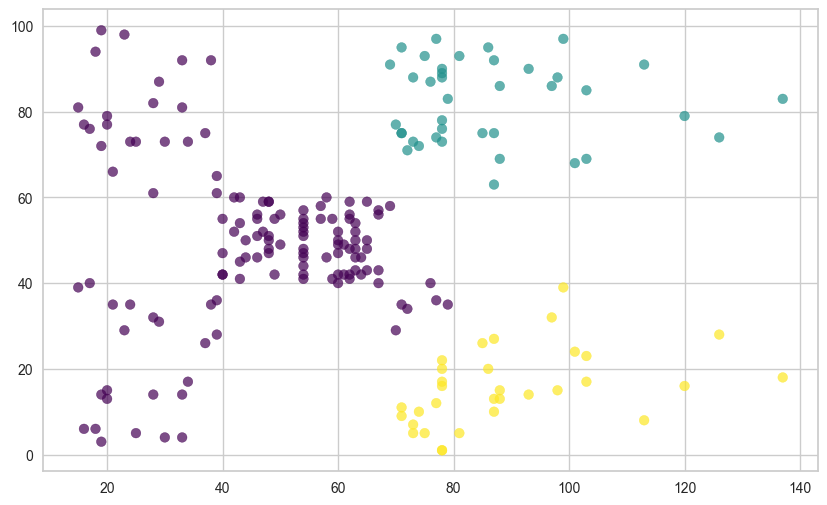

In [115]:
# Let's visualize the newly assigned observations to clusters (not drawn according to real values!!)

plt.scatter(X2_Hierarchy["Annual Income (k$)"], X2_Hierarchy["Spending Score (1-100)"], c= model1_X2.labels_, cmap= "viridis", alpha = 0.7);

Accoruding do graphic, we will update the clustring to use 5

In [116]:
model1_X2_updated =  AgglomerativeClustering(n_clusters=5,linkage = "ward") 
model1_X2_updated.fit_predict(X2_Hierarchy_scaled)

array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 2,
       4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 1, 2, 1, 0, 1, 0, 1,
       2, 1, 0, 1, 0, 1, 0, 1, 0, 1, 2, 1, 0, 1, 2, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 2, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1])

In [117]:
model1_X2_updated.labels_

array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 2,
       4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 1, 2, 1, 0, 1, 0, 1,
       2, 1, 0, 1, 0, 1, 0, 1, 0, 1, 2, 1, 0, 1, 2, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 2, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1])

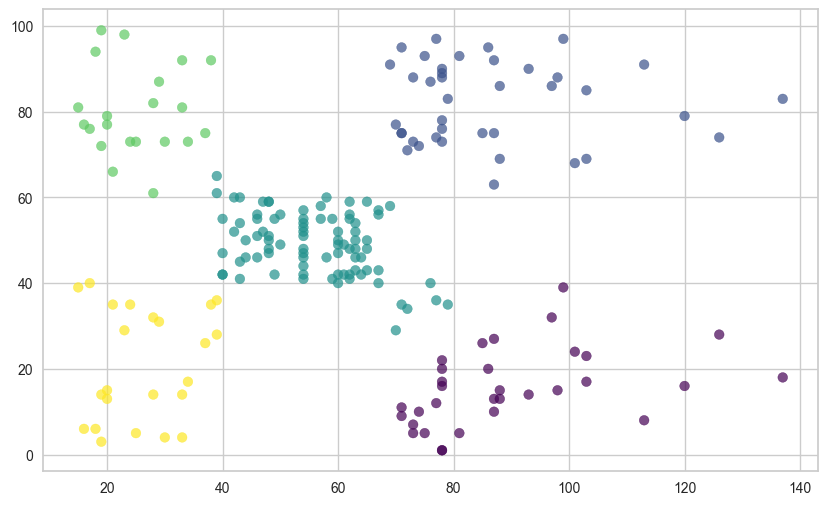

In [118]:
plt.scatter(X2_Hierarchy["Annual Income (k$)"], X2_Hierarchy["Spending Score (1-100)"], c= model1_X2_updated.labels_, cmap= "viridis", alpha = 0.7);

In [119]:
clusters_x2_hierarchy = model1_X2_updated.labels_      # I assigned my model predictions to the `clusters` variable.

In [120]:
X2_Hierarchy

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


In [121]:
X2_Hierarchy["predicted_clusters"] = clusters_x2_hierarchy    # added "predicted_clusters" feature to the original data
X2_Hierarchy.head()

,Annual Income (k$),Spending Score (1-100),predicted_clusters
0,15,39,4
1,15,81,3
2,16,6,4
3,16,77,3
4,17,40,4


### Final model fo X2

In [122]:
final_model_x2_hierarchy = AgglomerativeClustering(n_clusters=5, linkage = "complete")
clusters = final_model_x2_hierarchy.fit_predict(X2_Hierarchy)

In [124]:
X2_Hierarchy["predicted_clusters"] = clusters
X2_Hierarchy.head()

,Annual Income (k$),Spending Score (1-100),predicted_clusters
0,15,39,4
1,15,81,3
2,16,6,4
3,16,77,3
4,17,40,4


# Conclusion for X1 (Age vs Spending Score)

- Based on the clustering analysis of Age and Spending Score (X1), customers can be grouped into a few distinct segments. The results show that age plays an important role in spending behavior.

- Younger customers tend to have higher spending scores, while older customers generally show lower spending patterns. This indicates that younger individuals are more likely to spend more, whereas older customers are more conservative in their spending.
- Overall, this segmentation helps identify which age groups are more valuable in terms of spending and can help target marketing strategies accordingly.

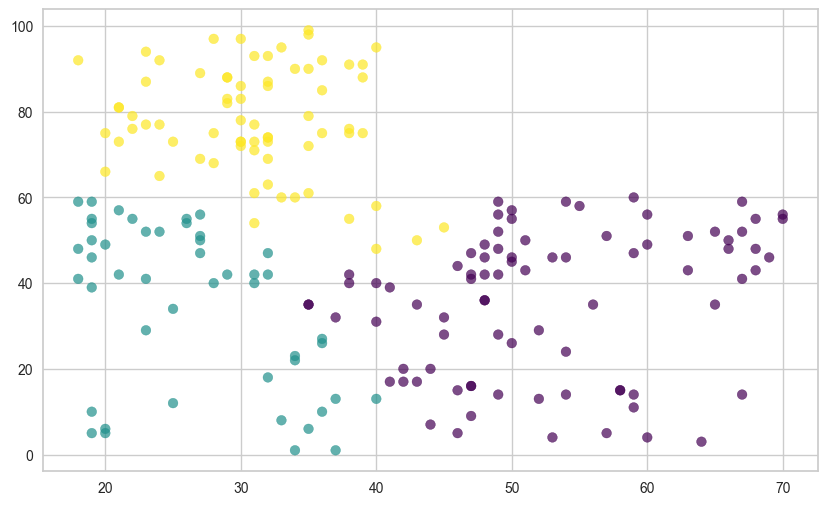

In [127]:
plt.scatter(X1_Hierarchy["Age"], X1_Hierarchy["Spending Score (1-100)"], c= model1_X1.labels_, cmap= "viridis", alpha = 0.7);

# Conclusion for X2 (Annual Income vs Spending Score)

- From the analysis of Annual Income and Spending Score (X2), clear customer segments are identified based on income and spending habits.

- The results show that customers with similar income levels can have very different spending behaviors. Some high-income customers spend a lot, while others spend very little. Similarly, some lower-income customers still show relatively high spending scores.

- This indicates that income alone does not determine spending behavior. Therefore, businesses should not rely only on income but also consider spending patterns when targeting customers.

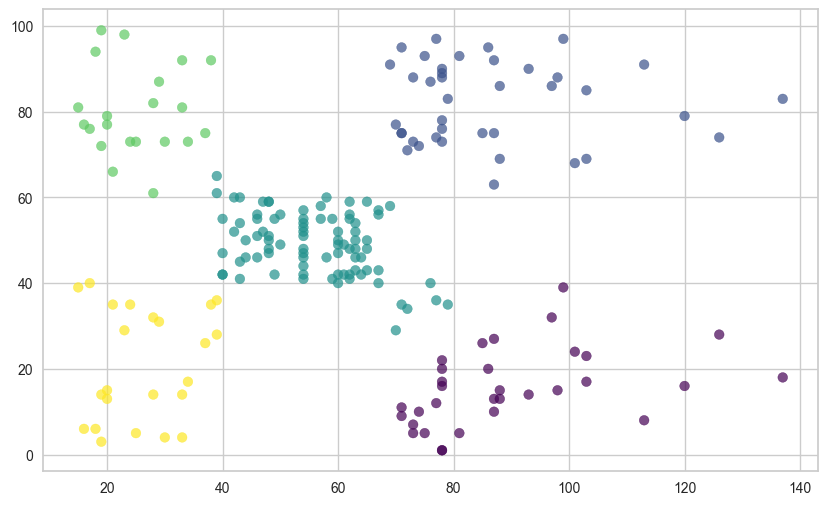

In [126]:
plt.scatter(X2_Hierarchy["Annual Income (k$)"], X2_Hierarchy["Spending Score (1-100)"], c= model1_X2_updated.labels_, cmap= "viridis", alpha = 0.7);